# 02 — Time Series Preparation (All Stations)

This notebook prepares cleaned water quality data for time-series analysis
by applying physical constraints, resampling to monthly frequency, and
ensuring temporal consistency across all monitoring stations.


Cell 2 — Import Library

In [1]:
import os
import pandas as pd
import numpy as np


Cell 3 — Define Paths

In [2]:
CLEAN_DIR = "../data/cleaned"
PREP_DIR = "../data/prepared"

os.makedirs(PREP_DIR, exist_ok=True)


Cell 4 — Define Physical Constraints (สำคัญมาก ⭐)

In [3]:
PHYSICAL_BOUNDS = {
    "secchi": (0, None),        # > 0
    "chlorophyll_a": (0, None),
    "tsi": (30, 80),            # typical TSI range
    "turbidity": (0, None),
    "salinity": (0, None),
    "do": (0, None),
    "ph": (0, 14)
}


Cell 5 — Function: Apply Physical Bounds

In [4]:
def apply_physical_bounds(df, bounds):
    df = df.copy()
    for col, (low, high) in bounds.items():
        if col not in df.columns:
            continue
        if low is not None:
            df.loc[df[col] < low, col] = np.nan
        if high is not None:
            df.loc[df[col] > high, col] = np.nan
    return df


Cell 6 — Loop Prepare Time Series (ALL Stations)

In [5]:
for file in os.listdir(CLEAN_DIR):
    if not file.endswith("_clean.csv"):
        continue

    station = file.replace("_clean.csv", "")
    path = os.path.join(CLEAN_DIR, file)

    df = pd.read_csv(path)

    # set date index
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()

    # apply physical constraints
    df = apply_physical_bounds(df, PHYSICAL_BOUNDS)

    # resample to monthly mean
    df_monthly = df.resample("ME").mean()

    # interpolate small gaps (time-based)
    df_monthly = df_monthly.interpolate(method="time")

    # save
    out_path = os.path.join(PREP_DIR, f"{station}_prepared.csv")
    df_monthly.to_csv(out_path)

    print(f"✅ Prepared: {station}")


✅ Prepared: CP01
✅ Prepared: LS01
✅ Prepared: LS03
✅ Prepared: PN01
✅ Prepared: SK01
✅ Prepared: SK06
✅ Prepared: TP011
✅ Prepared: TP01
✅ Prepared: TP04


Cell 7 — Quick Visual Check (1 Station)

In [6]:
sample = pd.read_csv(
    os.path.join(PREP_DIR, "CP01_prepared.csv"),
    parse_dates=["date"],
    index_col="date"
)

sample.head()


,secchi,chlorophyll_a,tsi,turbidity,salinity,do,ph
date,,,,,,,
2018-02-28,1.490897,13.044897,55.710300,104.961008,0.033180,9.577152,7.354302
2018-03-31,1.558243,13.298198,55.888606,104.579222,0.048582,9.577101,7.333727
2018-04-30,1.623415,13.543327,56.061161,104.209752,0.063487,9.577051,7.313816
2018-05-31,1.690761,13.796628,56.239468,103.827966,0.078889,9.577000,7.293242
2018-06-30,1.755933,14.041758,56.412022,103.458496,0.093793,9.576951,7.273331


Cell 8 — Plot Prepared vs Raw (Optional แต่ดีมาก)

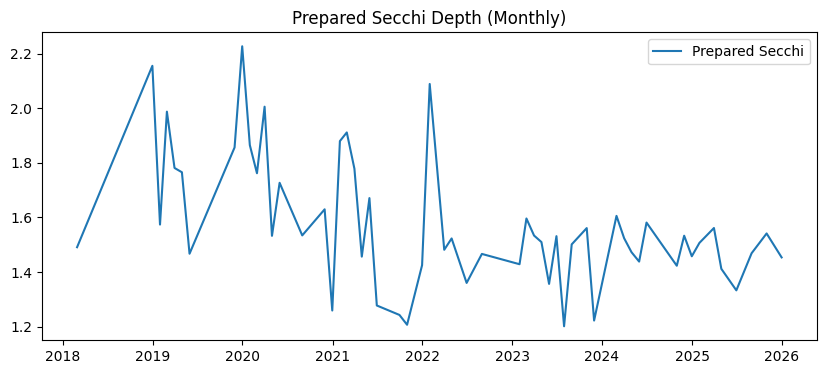

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(sample.index, sample["secchi"], label="Prepared Secchi")
plt.title("Prepared Secchi Depth (Monthly)")
plt.legend()
plt.show()
